# Model PCEX

Model PC is introduced in chapter 4 of {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` "Monetary Economics: An Integrated Approach to Credit, Money, Income, Production and Wealth". In its setup, the model has the same transactions and balance sheet as Model PC (see [here](GL06PC.ipynb)). 

## Module Contents

As with all `MacroStat` models, PCEX is divided into Variables, Parameters (fixed constants), Scenarios, and the Behavior (model initialization and steps). The module-level documentation, such as all variables/parameters/scenarios and their notation or the behavioral equations associated with each function of `BehaviorPCEX.py` can be seen in:

```{eval-rst}
.. toctree::
    :maxdepth: 2

    Variables <GL06PCEX/variables.rst>
    Parameters <GL06PCEX/parameters.rst>
    Equations <GL06PCEX/behavior.rst>
    Scenarios <GL06PCEX/scenarios.rst>
```

:::{Note}
The remainder of this page gives an introduction to the model, notes on how it is implemented in `MacroStat` and then shows some of the model dynamics by replicating the relevant graphs of Godley and Lavoie (2006).
:::

## Model Overview

### Behavioral Equations

Unlike model [PC](GL06PC.ipynb), model PCEX is built with expectations. Specifically, the household forms expectations of its disposable income $YD^e$ and its expected wealth $V^e$. With these two variables, the remaining equations of the model are almost identical to model PC.

1. National Income
```{math}
:label: gl06_pcex_eq401_nationalIncome
Y(t) = C(t) + G(t)
```
2. Disposable income is national income and interest earnings minus taxes
```{math}
:label: gl06_pcex_eq402_disposableIncome
YD(t) = Y(t) - T(t) + r(t-1)\cdot B_h(t-1)
```
3. Taxes are a fixed share of income
```{math}
:label: gl06_pcex_eq403_taxes
T(t) = \Theta \cdot \left(Y(t) + r(t-1)\cdot B_h(t-1)\right)
```
4. Wealth increases by savings
```{math}
:label: gl06_pcex_eq404_wealth
V(t) = V(t-1) + (YD(t) - C(t))
```
5. Consumption is partially out of disposable income and wealth, **but now based on expected disposable income**
```{math}
:label: gl06_pcex_eq405E_consumption
C(t) = \alpha_1\cdot YD^e(t) + \alpha_2\cdot V(t-1)
```
6. The share of bills in wealth depends on **expected wealth and expected disposable income**
```{math}
:label: gl06_pcex_eq407E_householdBondHoldings
\frac{B_d(t)}{V^e(t)}=\lambda_0 + \lambda_1\cdot r(t) - \lambda_2\cdot\left(\frac{YD^e(t)}{V^e(t)}\right)
```
7. The share of cash in wealth (6A)
```{math}
:label: gl06_pcex_eq406E_householdCashHoldings
\frac{H_d(t)}{V^e(t)}=(1-\lambda_0) - \lambda_1\cdot r(t) + \lambda_2\cdot\left(\frac{YD^e(t)}{V^e(t)}\right)
```
8. Household cash demand can also be described by the difference between **expected wealth** and **demand for bills**
```{math}
:label: gl06_pcex_eq413_householdDepositDemand
H_d(t) = V^e(t) - B_h(t)
```
8. **expected wealth** depends on **expected disposable income**
```{math}
:label: gl06_pcex_eq414_householdExpectedWealth
V^e(t) = V(t-1) + (YD^e(t) - C(t))
```
9. The household's realized cash holdings then depend on the realisation of household wealth
```{math}
:label: gl06_pcex_eq406_householdDeposits
H_h(t) = V(t) - B_h(t)
```
10. Where we assume now that the household's demand for bills is met.
```{math}
:label: gl06_pcex_eq415_householdBillHoldings
B_h(t) = B_d(t)
```
11. The change in the stock of outstanding government bills (also known as the government's budget constraint). The first part represents government outlays (direct purchases and interest payments) while the second represents government revenues (taxes and central bank profits)
```{math}
:label: gl06_pcex_eq408_governmentBillIssuance
:nowrap:

\begin{align}
\Delta B_s(t) &= B_s(t) - B_s(t-1)\\
&= (G(t) + r(t-1)\cdot B_s(t-1)) - (T(t) + r(t-1)\cdot B_{CB}(t-1))
\end{align}
```
12. The change in money circulating 
```{math}
:label: gl06_pcex_eq409_moneyIssuance
\Delta H_s(t) = H_s(t) - H_s(t-1) = \Delta B_{CB}
```
13. Bills held by the central bank, the central bank purchases all of the bills issued by the government that the households are not willing to buy given the current interest rate. Combined with {eq}`gl06_pc_eq409_moneyIssuance` it implies the CB provides cash money on demand. Therefore, _the amount of cash in the system is endogeneous and demand-led_ while _the rate on bills is exogenous_.
```{math}
:label: gl06_pcex_eq410_centralBankBills
B_{CB}(t) = B_s(t) - B_h(t)
```
13. The interest rate is fixed
```{math}
:label: gl06_pc_eq411_interestRate
r(t) = \bar{r}
```

With the redundant equation being
```{math}
:label: gl06_pc_eq412_redundant
H_s(t) = H_h(t)
```

**Now we must still define how the expected disposable income is set**, as with model [SIMEX](GL06SIMEX.ipynb), we suppose that it is a simple extrapolation from prior levels (which is self-consistent in a steady state since the economy is not growing here). 
```{math}
:label: gl06_pcex_eq416_expectedDisposableIncome
YD^e(t) = YD(t-1)
```
Note that in {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` this is equivalent to _Model PCEX1_, while _Model PCEX_ actually just assumes a random multiplicative term on the $YD$ determined by model PC. I do not here model this part, as it is only used as a demonstration in the book. 


### Transaction Flow Matrix

```{csv-table} Accounting Transaction Matrix for Model PC
:file: GL06PCEX/transaction_matrix.csv
:header-rows: 2
:stub-columns: 1
```

### Balance Sheet Matrix

```{csv-table} Balance Sheet for Model PC
:file: GL06PCEX/balance_sheet.csv
:header-rows: 2
:stub-columns: 1
```

## Implementation in MacroStat

Transposing these eleven equations to the `MacroStat` framework, we consider that there are:

1. Three parameters (fixed constants): $\alpha_1$, $\alpha_2$, and $\theta$ (see [Parameters](GL06SIM/parameters.rst))
2. Two scenario variables : $G_d(t)$ and $W(t)$ (see [Scenarios](GL06SIM/scenarios.rst))
3. The remaining tracked series are variables (see [Variables](GL06SIM/variables.rst))

## Model Dynamics

### Preparatory Steps

In [1]:
%load_ext autoreload
%autoreload 2

import importlib
import logging
import sys

from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
from macrostat.models import get_model
import numpy as np

plt.style.use("../../macrostat.mplstyle")
importlib.reload(logging)
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG)

### Running the Simulation

First, we can run the model without any shocks to see the convergence to the steady state.

In [31]:
GL06PCEX = get_model("GL06PCEX")
model = GL06PCEX()
model.simulate()
output = model.variables.to_pandas()

INFO:root:Starting simulation. Scenario: 0


Here we can also check that the variables are healthy, which means that the redundant equations hold and that all the assets and liabilities are positive. For model PC, the redundant equation is that the household money stock equals the central bank money stock. 

:::{Note}
In numerical implementations, due to floating point precision it is unlikely that the redundant equation will hold exactly. Therefore, we check that the absolute percentage error is less than a given tolerance, in this case 1e-5. We use the absolute percentage error to appropriately scale the error for different magnitudes of the variables.
:::

In [32]:
model.variables.check_health(tolerance=1e-5)

True

In [33]:
df=model.variables.to_pandas()
df.head(10).T

,,0,1,2,3,4,5,6,7,8,9
ConsumptionHousehold,0,0.0,0.0,0.000,16.000000,28.799999,39.280003,47.856003,54.874001,60.617043,65.316742
ConsumptionGovernment,0,0.0,0.0,20.000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
NationalIncome,0,0.0,0.0,20.000,36.000000,48.799999,59.280003,67.856003,74.874001,80.617043,85.316742
InterestEarnedOnBillsHousehold,0,0.0,0.0,0.000,0.000000,0.300000,0.540000,0.736500,0.897300,1.028887,1.136569
InterestEarnedOnBillsCentralBank,0,0.0,0.0,0.000,0.400000,0.420000,0.442000,0.459900,0.474550,0.486539,0.496349
CentralBankProfits,0,0.0,0.0,0.000,0.400000,0.420000,0.442000,0.459900,0.474550,0.486539,0.496349
Taxes,0,0.0,0.0,4.000,7.200000,9.820000,11.964001,13.718501,15.154261,16.329185,17.290663
HouseholdMoneyStock,0,0.0,0.0,16.000,16.799999,17.680004,18.396004,18.981991,19.461540,19.853958,20.175072
CentralBankMoneyStock,0,0.0,0.0,16.000,16.800003,17.680002,18.396004,18.981995,19.461544,19.853966,20.175095
HouseholdBillStock,0,0.0,0.0,0.000,12.000000,21.599998,29.459995,35.892002,41.155495,45.462776,48.987556


### Convergence to the Steady State

The steady state for Model PCEX is equivalent to model PC, it just has delays in reathing the steady state. In {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated` models are initialized with almost all of the variables set to zero. For model PCEX the only non-zero item is that in period 0 the government demand is 20, i.e. the government creates 20 monetary units of demand.

#### Steady State solutions

To aid in our graphing, we can calculate the steady state solutions for the variables following the derivations in Section 4.5 of Godley and Lavoie {cite:t}`GodleyLavoie2006MonetaryEconomicsIntegrated`.

First, we set some helper variables, using `r` for the interest rate and `g` for the government demand. Then defining 
```{math}
\alpha_3 = \frac{1-\alpha_1}{\alpha_2}
```
we can solve for the steady state values of the variables.


In [34]:
steadystate = {}
p = model.parameters
a3 = (1-p["PropensityToConsumeIncome"]) / p["PropensityToConsumeSavings"]
r = model.scenarios[(0,"InterestRate")][0]
g = model.scenarios[(0,"GovernmentDemand")][0]

The steady state disposable income is given by
```{math}
YD^\star = \frac{g}{\frac{\theta}{1-\theta} - r\cdot\left(\left(\lambda_0 + \lambda_1 r \right)\alpha_3 - \lambda_2\right)}
```

In [35]:
steadystate["DisposableIncome"] = g /  (
    (p["TaxRate"] / (1-p["TaxRate"]))
    - r * ((p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) * a3 - p["WealthShareBills_Income"])
)

The steady state household bill holdings are given by
```{math}
B_h^\star = \left(\left(\lambda_0 + \lambda_1 r \right)\alpha_3 - \lambda_2\right)\cdot YD^\star
```
and the steady state wealth is given by
```{math}
V^\star = \frac{YD^\star}{\alpha_3}
```


In [36]:
steadystate["HouseholdBillStock"] = (
    a3 * (p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) - p["WealthShareBills_Income"]
    ) * steadystate["DisposableIncome"]
steadystate["Wealth"] = steadystate["DisposableIncome"] / a3

Finally, the steady state national income is given by
```{math}
Y^\star = YD^\star + g
```
since 
```{math}
C^\star = YD^\star
```



In [37]:
steadystate["NationalIncome"] = steadystate["DisposableIncome"] + g
steadystate["Consumption"] = steadystate["DisposableIncome"]

#### Convergence to the Steady State

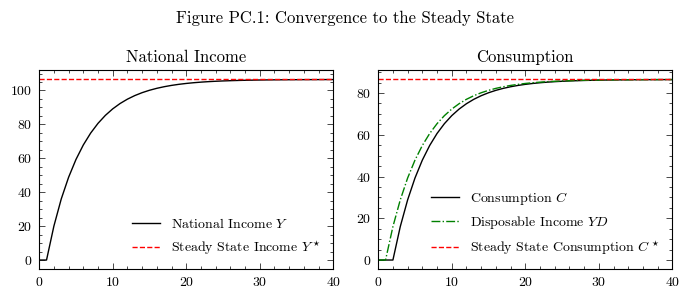

In [38]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
axs[0].plot(output.index, output['NationalIncome'], color='k', label=r'National Income $Y$')
axs[0].axhline(y=steadystate["NationalIncome"], color='r', linestyle='--', label=r'Steady State Income $Y^\star$')
axs[0].legend(loc='lower right', frameon=False)
axs[0].set_xlim(0,40)
axs[0].set_title('National Income')
axs[1].plot(output.index, output['ConsumptionHousehold'], color='k', label=r'Consumption $C$')
axs[1].plot(output.index, output['DisposableIncome'], color='g', linestyle='-.', label=r'Disposable Income $YD$')
axs[1].axhline(y=steadystate["Consumption"], color='r', linestyle='--', label=r'Steady State Consumption $C^\star$')
axs[1].legend(loc='lower right', frameon=False)
axs[1].set_xlim(0,40)
axs[1].set_title('Consumption')
fig.suptitle('Figure PC.1: Convergence to the Steady State')
plt.tight_layout()
plt.show()


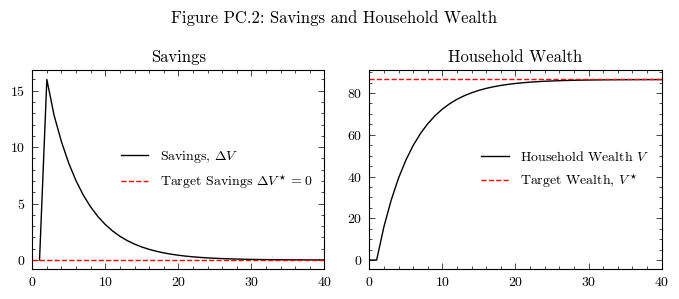

In [39]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))

# Left panel - Savings
line1 = axs[0].plot(output.index, output['Wealth'].diff(), color='k', linestyle='-', label='Savings, $\Delta V$')
line2 = axs[0].axhline(y=0, color='r', linestyle='--', label='Target Savings $\Delta V^\star=0$')
axs[0].legend(loc='center right', frameon=False)
axs[0].set_xlim(0,40)
axs[0].set_title('Savings')

# Right panel - Wealth
line3 = axs[1].plot(output.index, output['Wealth'], color='k', linestyle='-', label='Household Wealth $V$')
line4 = axs[1].axhline(y=steadystate["Wealth"], color='r', linestyle='--', label='Target Wealth, $V^\star$')
axs[1].legend(loc='center right', frameon=False)
axs[1].set_xlim(0,40)
axs[1].set_title('Household Wealth')

fig.suptitle('Figure PC.2: Savings and Household Wealth')
plt.tight_layout()
plt.show()


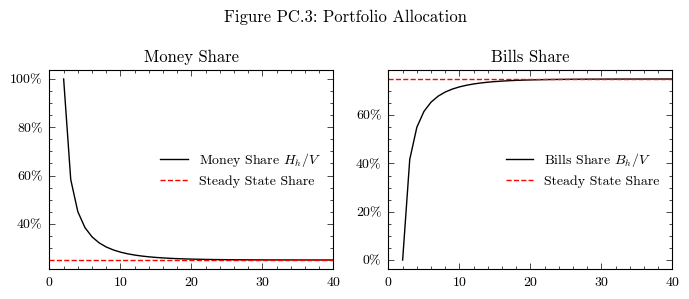

In [40]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
share_bills = steadystate['HouseholdBillStock'] / steadystate['Wealth']
# Left panel - Money share
money_share = output['HouseholdMoneyStock'] / output['Wealth']
line1 = axs[0].plot(output.index, money_share, color='k', linestyle='-', label='Money Share $H_h/V$')
axs[0].axhline(y=1-share_bills, color='r', linestyle='--', label='Steady State Share')
axs[0].legend(loc='center right', frameon=False)
axs[0].set_xlim(0,40)
axs[0].set_title('Money Share')
axs[0].yaxis.set_major_formatter(PercentFormatter(1))

# Right panel - Bills share
bills_share = output['HouseholdBillStock'] / output['Wealth']
line3 = axs[1].plot(output.index, bills_share, color='k', linestyle='-', label='Bills Share $B_h/V$')
axs[1].axhline(y=share_bills, color='r', linestyle='--', label='Steady State Share')
axs[1].legend(loc='center right', frameon=False)
axs[1].set_xlim(0,40)
axs[1].set_title('Bills Share')
axs[1].yaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle('Figure PC.3: Portfolio Allocation')
plt.tight_layout()
plt.show()


### Perturbations in the Steady State: An increase in the propensity to consume out of income ($\alpha_1$)

Following the convergence to the steady state, we can study the effects of an increase of the household sector's propensity to consume out of income. 

`MacroStat` is set up to easily handle time-dependent changes in the values of parameters (useful for scenarios and calibration). It specifically supports two types of paramer-shocks: multiplicative and additive. Thus, if `pname` is the name of the parameter, it checks for the existence of `pname_multiply` and `pname_add` in the scenarios to edit them. 

Therefore, let us add this kind of scenario can easily be implemented in the `MacroStat` version by adding a scenario:
1. In the file `Scenarios` specific to `GL06PC` (i.e. `macrostat/models/GL06PC/scenarios.py`) I added the `PropensityToConsumeIncome_add` default_value, and set it to zero. 
2. Noting that we have convergence to the steady state at period 60, let us set this as the scenario trigger
3. We then need a new timeseries for the scenario, where we have `PropensityToConsumeIncome_add=0.01`

In [11]:
model.parameters["scenario_trigger"] = 60
model.scenarios.add_scenario(
    name="PropensityToConsumeIncomeIncrease",
    timeseries={"PropensityToConsumeIncome_add":0.01}
)
model.simulate(scenario="PropensityToConsumeIncomeIncrease")
output_interest_rate_increase = model.variables.to_pandas()

INFO:root:Starting simulation. Scenario: 1


We then need to compute the new steady state values for the variables

In [12]:
steadystate_cons_propensity_increase = {}
p = model.parameters
a3 = (1-p["PropensityToConsumeIncome"]) / p["PropensityToConsumeSavings"]
r = model.scenarios[(1,"InterestRate")][-1]
g = model.scenarios[(1,"GovernmentDemand")][-1]

steadystate_cons_propensity_increase["DisposableIncome"] = g /  (
    (p["TaxRate"] / (1-p["TaxRate"]))
    - r * ((p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) * a3 - p["WealthShareBills_Income"])
)

steadystate_cons_propensity_increase["HouseholdBillStock"] = (
    a3 * (p["WealthShareBills_Constant"] + p["WealthShareBills_InterestRate"] * r) - p["WealthShareBills_Income"]
    ) * steadystate_cons_propensity_increase["DisposableIncome"]
steadystate_cons_propensity_increase["Wealth"] = steadystate_cons_propensity_increase["DisposableIncome"] / a3

steadystate_cons_propensity_increase["NationalIncome"] = steadystate_cons_propensity_increase["DisposableIncome"] + g
steadystate_cons_propensity_increase["Consumption"] = steadystate_cons_propensity_increase["DisposableIncome"]


Now we can see how the model reacts to the shock.

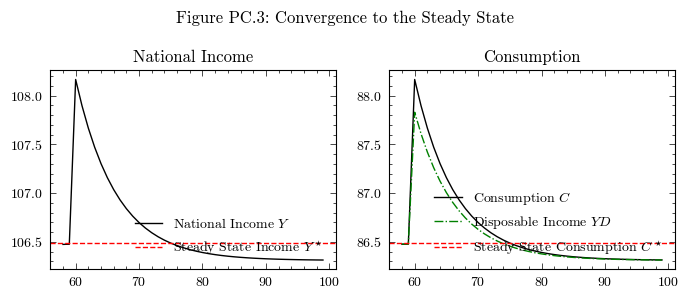

In [13]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
df = output_interest_rate_increase.loc[model.parameters["scenario_trigger"]-2:]
axs[0].plot(df.index, df['NationalIncome'], color='k', label=r'National Income $Y$')
axs[0].axhline(y=steadystate_cons_propensity_increase["NationalIncome"], color='r', linestyle='--', label=r'Steady State Income $Y^\star$')
axs[0].legend(loc='lower right', frameon=False)
axs[0].set_title('National Income')
axs[1].plot(df.index, df['ConsumptionHousehold'], color='k', label=r'Consumption $C$')
axs[1].plot(df.index, df['DisposableIncome'], color='g', linestyle='-.', label=r'Disposable Income $YD$')
axs[1].axhline(y=steadystate_cons_propensity_increase["Consumption"], color='r', linestyle='--', label=r'Steady State Consumption $C^\star$')
axs[1].legend(loc='lower right', frameon=False)
axs[1].set_title('Consumption')
fig.suptitle('Figure PC.3: Convergence to the Steady State')
plt.tight_layout()
plt.show()


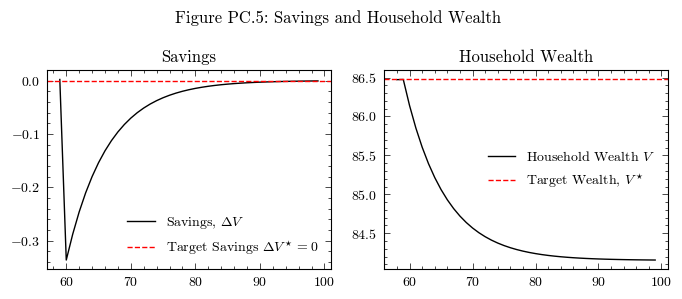

In [14]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
df = output_interest_rate_increase.loc[model.parameters["scenario_trigger"]-2:]

# Left panel - Savings
line1 = axs[0].plot(df.index, df['Wealth'].diff(), color='k', linestyle='-', label='Savings, $\Delta V$')
line2 = axs[0].axhline(y=0, color='r', linestyle='--', label='Target Savings $\Delta V^\star=0$')
axs[0].legend(frameon=False)
axs[0].set_title('Savings')

# Right panel - Wealth
line3 = axs[1].plot(df.index, df['Wealth'], color='k', linestyle='-', label='Household Wealth $V$')
line4 = axs[1].axhline(y=steadystate_cons_propensity_increase["Wealth"], color='r', linestyle='--', label='Target Wealth, $V^\star$')
axs[1].legend(frameon=False)
axs[1].set_title('Household Wealth')

fig.suptitle('Figure PC.5: Savings and Household Wealth')
plt.tight_layout()
plt.show()


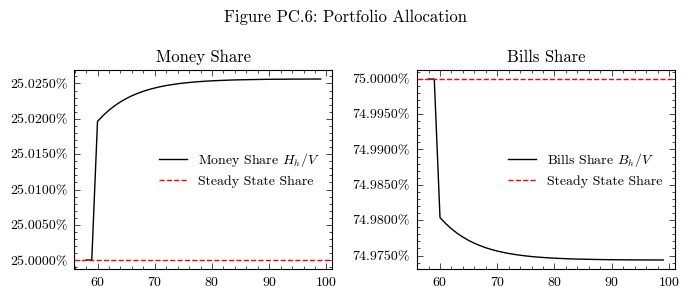

In [15]:
fig, axs = plt.subplots(ncols=2, nrows=1, figsize=(7, 3))
share_bills = steadystate_cons_propensity_increase['HouseholdBillStock'] / steadystate_cons_propensity_increase['Wealth']
df = output_interest_rate_increase.loc[model.parameters["scenario_trigger"]-2:]
# Left panel - Money share
money_share = df['HouseholdMoneyStock'] / df['Wealth']
line1 = axs[0].plot(df.index, money_share, color='k', linestyle='-', label='Money Share $H_h/V$')
axs[0].axhline(y=1-share_bills, color='r', linestyle='--', label='Steady State Share')
axs[0].legend(loc='center right', frameon=False)
axs[0].set_title('Money Share')
axs[0].yaxis.set_major_formatter(PercentFormatter(1))

# Right panel - Bills share
bills_share = df['HouseholdBillStock'] / df['Wealth']
line3 = axs[1].plot(df.index, bills_share, color='k', linestyle='-', label='Bills Share $B_h/V$')
axs[1].axhline(y=share_bills, color='r', linestyle='--', label='Steady State Share')
axs[1].legend(loc='center right', frameon=False)
axs[1].set_title('Bills Share')
axs[1].yaxis.set_major_formatter(PercentFormatter(1))

fig.suptitle('Figure PC.6: Portfolio Allocation')
plt.tight_layout()
plt.show()
